In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

try:
    import snowflake.connector
except:
    ! pip install snowflake-connector-python
    import snowflake.connector

from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives.asymmetric import rsa, dsa
from cryptography.hazmat.primitives import serialization

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-02-28 20:38:01.610978


#### Functions

In [3]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [4]:
# newest payloads
str_uri_new = 's3://20250121-gen-13-model-monitoring/10_compare_debtor/df.gzip'

# old payloads
str_uri = 's3://20241112-simple-model-test/08_prep_data/df.gzip'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# pd threshold
flt_threshold_pd = 0.6

#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Snowflake funded accounts

In [6]:
# load 
str_filename = 'datascience_rsa_key.p8'
str_local_path = f'./{str_filename}'
with open(str_local_path, "rb") as key:
    p_key = serialization.load_pem_private_key(
        key.read(),
        password=None,
        backend=default_backend(),
    )
# convert to bytes
private_key = p_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption(),
)
# connect to snowflake
conn = snowflake.connector.connect(
    user='datascience', 
    private_key=private_key,
    account='pfs', 
    warehouse='datascience',
    database='raw',
    schema='source_s3_scorehistory',
)

In [7]:
str_filename = 'query.sql'
str_local_path = f'./query/{str_filename}'
str_query = open(str_local_path, 'r').read()

In [8]:
# pull funded
df_funded = pd.read_sql(
    sql=str_query,
    con=conn,
)

df_funded.rename(columns={'ACCOUNT_NUMBER':'accountid',
                         'APPLICATION_DATE':'app_date'}, inplace=True
                )

df_funded = df_funded[['accountid']]

# show
df_funded.shape

/tmp/ipykernel_29752/3371674540.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_funded = pd.read_sql(


(73449, 1)

#### Load data new

In [9]:
df_new = pd.read_parquet(str_uri_new)

# group by
df_new = df_new.groupby('accountid').agg({
    'request_datetime':'first',    
#     'pd_gen12': 'mean', 
#     'lgd_gen12': 'mean',
    'rp01s__tu':'sum',    
#     'ENG-wtd_avg': 'mean',    
    'ENG-loan_to_value':'first',
    'g106s__tu':'mean',
    'g232s__tu':'max',
}).reset_index()

# get monthly request datetime format
df_new['request_datetime'] = pd.to_datetime(df_new['request_datetime'], utc=True)
df_new['request_datetime'] = pd.to_datetime(df_new['request_datetime']).dt.strftime('%Y-%m')

# # group by at monthly level to do over time analysis
# df_new = df_new.groupby('request_datetime').agg({
#     'accountid':'first',
#     'rp01s__tu':'mean',
#     'ENG-loan_to_value':'mean',
#     'g106s__tu':'mean',
#     'g232s__tu':'mean',
# #     'ENG-wtd_avg':'mean',
# }).reset_index()

# show
df_new

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:283: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,accountid,request_datetime,rp01s__tu,ENG-loan_to_value,g106s__tu,g232s__tu
0,5782431,2024-12,1.0,1.270000,413.0,1.0
1,7861802,2024-12,0.0,1.074516,159.0,31.0
2,7986128,2024-12,-4.0,1.061934,346.0,16.0
3,8033187,2025-01,0.0,1.231172,358.0,12.0
4,8155274,2024-12,0.0,1.261982,318.0,12.0
...,...,...,...,...,...,...
146635,8694760,2025-02,1.0,1.148041,59.0,18.0
146636,8694762,2025-02,0.0,0.918839,302.5,13.0
146637,8694763,2025-02,0.0,1.023583,324.5,27.0
146638,8694764,2025-02,0.0,1.122442,229.0,19.0


In [10]:
# load
df_old = pd.read_parquet(str_uri)

# group by
df_old = df_old.groupby('accountid').agg({
    'request_datetime':'first',    
    'rp01s__tu':'sum',    
#     'ENG-wtd_avg': 'mean',    
    'ENG-loan_to_value':'first',
    'g106s__tu':'mean',
    'g232s__tu':'max',
}).reset_index()

# get monthly request datetime format
df_old['request_datetime'] = pd.to_datetime(df_old['request_datetime'], utc=True)
df_old['request_datetime'] = pd.to_datetime(df_old['request_datetime']).dt.strftime('%Y-%m')


# # group by at monthly level to do over time analysis
# df_old = df_old.groupby('request_datetime').agg({
#     'accountid':'first',
#     'rp01s__tu':'mean',
#     'ENG-loan_to_value':'mean',
#     'g106s__tu':'mean',
#     'g232s__tu':'mean',
# #     'ENG-wtd_avg':'mean',
# }).reset_index()

# show
df_old

,accountid,request_datetime,rp01s__tu,ENG-loan_to_value,g106s__tu,g232s__tu
0,5514485,2022-10,0.0,1.299997,351.0,6.0
1,5514970,2022-10,0.0,1.295059,118.0,11.0
2,5515245,2022-10,0.0,1.156227,195.0,12.0
3,5515340,2022-10,0.0,1.599743,277.0,7.0
4,5515580,2022-10,0.0,1.363642,182.0,12.0
...,...,...,...,...,...,...
78143,8420461,2024-11,1.0,1.585118,264.0,10.0
78144,8420588,2024-11,1.0,1.280957,268.0,15.0
78145,8420665,2024-11,0.0,1.189153,339.0,9.0
78146,8421889,2024-11,0.0,1.082309,61.0,4.0


#### Concat new and old and remove dupes

In [11]:
# concat
df_combined = pd.concat([df_old, df_new])

# drop duplicates keep first
df_combined = df_combined.drop_duplicates(keep='first')

# show
df_combined

,accountid,request_datetime,rp01s__tu,ENG-loan_to_value,g106s__tu,g232s__tu
0,5514485,2022-10,0.0,1.299997,351.0,6.0
1,5514970,2022-10,0.0,1.295059,118.0,11.0
2,5515245,2022-10,0.0,1.156227,195.0,12.0
3,5515340,2022-10,0.0,1.599743,277.0,7.0
4,5515580,2022-10,0.0,1.363642,182.0,12.0
...,...,...,...,...,...,...
146635,8694760,2025-02,1.0,1.148041,59.0,18.0
146636,8694762,2025-02,0.0,0.918839,302.5,13.0
146637,8694763,2025-02,0.0,1.023583,324.5,27.0
146638,8694764,2025-02,0.0,1.122442,229.0,19.0


#### L join onto all funded accounts

In [12]:
# merge
df_apps = pd.merge(df_funded, df_combined, how='left', on='accountid')

# remove direct lending accounts (NaN datetime) after joining with funded
df_apps = df_apps.dropna(subset=['request_datetime'])

# show
df_apps

# delete stuff we dont need to save memory
del df_combined, df_new, df_old, df_funded

#### group by date with final df

In [13]:
# group by at monthly level to do over time analysis
df_apps = df_apps.groupby('request_datetime').agg({
    'accountid':'first',
    'rp01s__tu':'mean',
    'ENG-loan_to_value':'mean',
    'g106s__tu':'mean',
    'g232s__tu':'mean',
#     'ENG-wtd_avg':'mean',
}).reset_index()

# show
df_apps

,request_datetime,accountid,rp01s__tu,ENG-loan_to_value,g106s__tu,g232s__tu
0,2022-01,5872219,0.170503,1.271622,240.388747,14.035806
1,2022-02,5918307,0.179195,1.270063,231.689307,14.142569
2,2022-03,5937118,0.187013,1.265967,221.478571,13.922078
3,2022-04,6034248,0.191791,1.270350,227.513425,13.586881
4,2022-05,6023709,0.177626,1.267002,234.283364,13.881627
5,2022-06,6070056,0.191743,1.280641,233.371887,13.893893
6,2022-07,6150614,0.159483,1.277669,251.345785,13.940134
7,2022-08,6206264,0.163756,1.287559,249.165308,13.742336
8,2022-09,6293254,0.144176,1.283113,248.637962,13.855824
9,2022-10,6363051,0.157701,1.290468,249.330693,13.836772


#### Plots

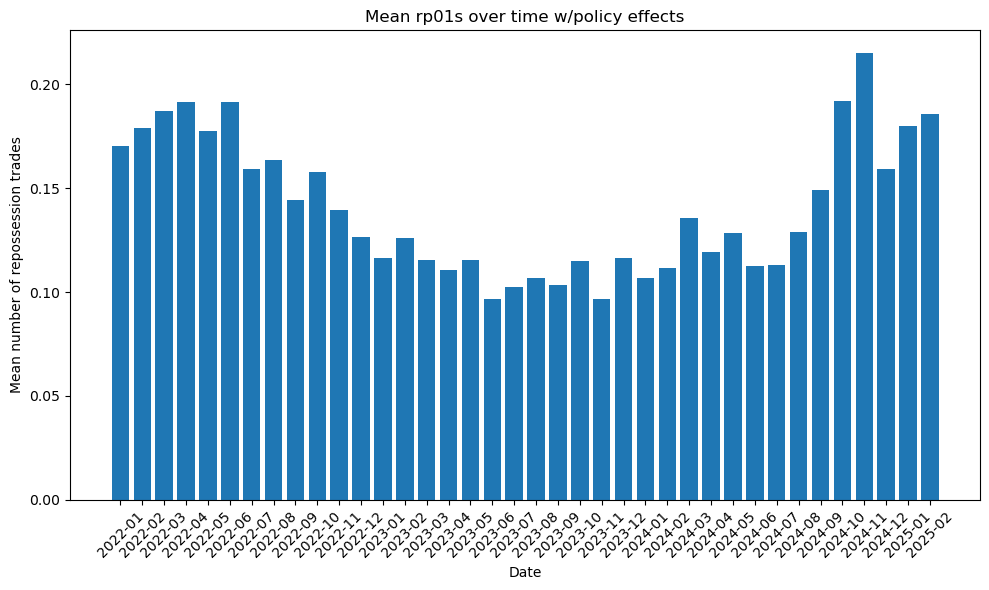

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['rp01s__tu'])

# Labeling
plt.title('Mean rp01s over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean number of repossession trades')

# rotate x axis 
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

In [15]:
# plt.figure(figsize=(10, 6))
# plt.bar(df_apps['request_datetime'], df_apps['ENG-wtd_avg'])

# # label
# plt.title('Mean wtd_avg over time w/policy effects')
# plt.xlabel('Date')
# plt.ylabel('Mean of wtd_avg')

# # rotate x axis
# plt.xticks(rotation=45)

# # show
# plt.tight_layout()
# plt.show()

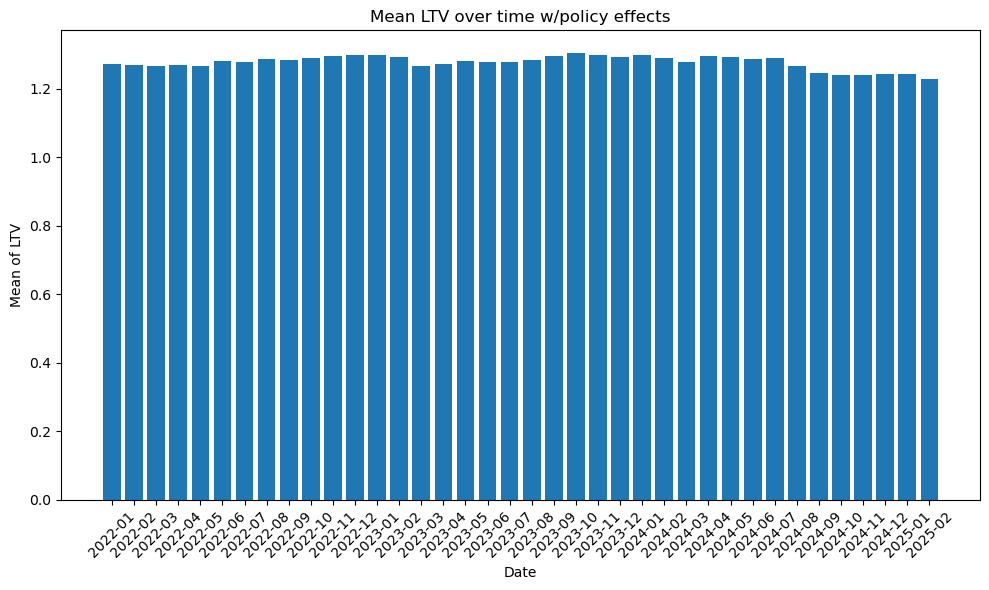

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['ENG-loan_to_value'])

# label
plt.title('Mean LTV over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean of LTV')

# rotate for better readability
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

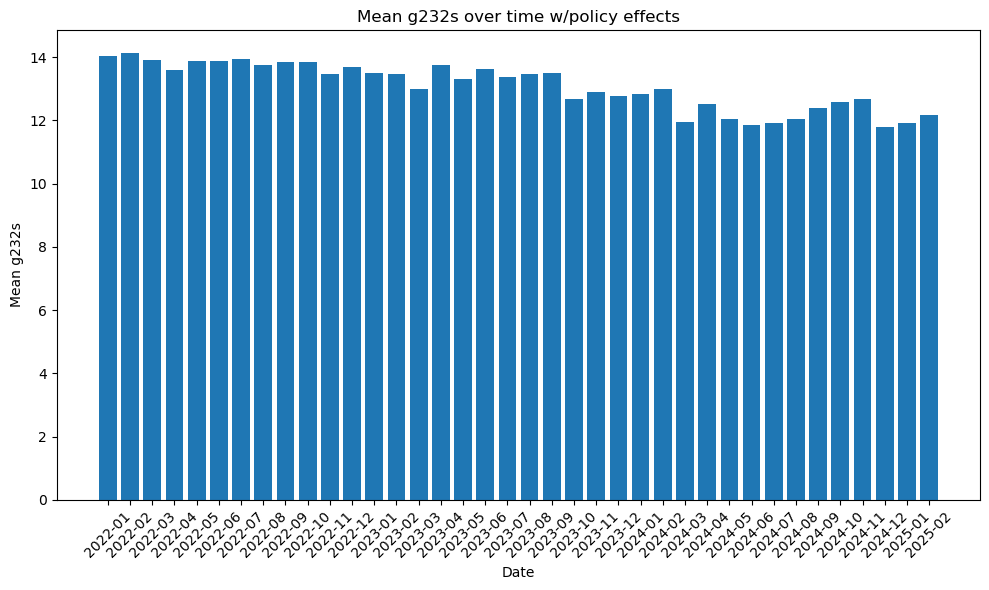

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['g232s__tu'])

# label
plt.title('Mean g232s over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean g232s')

# rotate x axis
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()

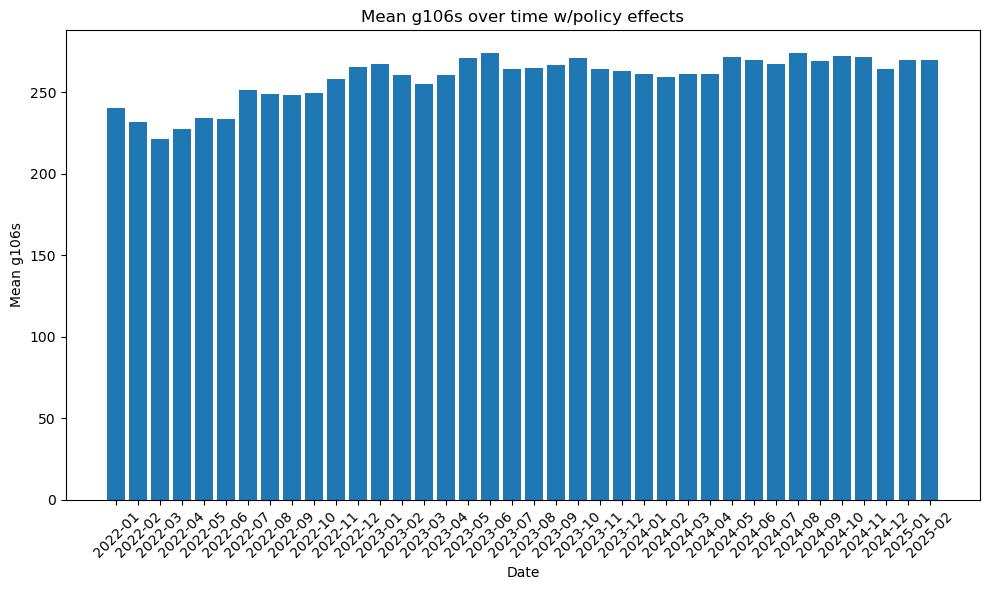

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(df_apps['request_datetime'], df_apps['g106s__tu'])

# labeling
plt.title('Mean g106s over time w/policy effects')
plt.xlabel('Date')
plt.ylabel('Mean g106s')

# rotate
plt.xticks(rotation=45)

# show
plt.tight_layout()
plt.show()